In [1]:
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


In [2]:
from torch.utils.data import DataLoader
from eb_jepa.datasets.moving_mnist import MovingMNISTDet


train_set = MovingMNISTDet(split="train")
val_set   = MovingMNISTDet(split="val")

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2)

In [3]:
batch = next(iter(train_loader))
print(batch["video"].shape)

torch.Size([64, 1, 10, 64, 64])


In [4]:
from architectures import (
    ResNet5,
    ResUNet, 
    StateOnlyPredictor,
    Projector,
    DetHead
    )

from jepa import JEPA, JEPAProbe
from image_decoder import ImageDecoder
from losses import VCLoss, SquareLossSeq
from eb_jepa.training_utils import load_config



fname = "cfgs/default.yaml"
cfg = load_config(fname)

encoder = ResNet5(cfg.model.dobs, cfg.model.henc, cfg.model.dstc)
predictor_model = ResUNet(2 * cfg.model.dstc, cfg.model.hpre, cfg.model.dstc, is_rnn= False)    # is_rnn = False is default (being explicit).
predictor = StateOnlyPredictor(predictor_model,context_length=2)
projector = Projector(f"{cfg.model.dstc}-{cfg.model.dstc*4}-{cfg.model.dstc*4}")
regularizer = VCLoss(cfg.loss.std_coeff, cfg.loss.cov_coeff, proj=projector)
ploss = SquareLossSeq(projector)
jepa = JEPA(encoder, encoder, predictor, regularizer, ploss).to(device)

# Initialize decoder and detection head (for evaluation only)
decoder = ImageDecoder(cfg.model.dstc, cfg.model.dobs)
dethead = DetHead(cfg.model.dstc, cfg.model.hpre, cfg.model.dobs)
pixel_decoder = JEPAProbe(jepa, decoder, nn.MSELoss()).to(device)
detection_head = JEPAProbe(jepa, dethead, nn.BCELoss()).to(device)

[INFO    ][2026-07-08 07:40:59][eb_jepa.training_utils][load_config              ] Loaded config from cfgs/default.yaml


In [5]:
jepa_ckpt_20        = torch.load("artifacts/epoch_20.pth.tar", map_location= device)
decoder_ckpt_latest = torch.load("artifacts/decoder_latest.pth.tar", map_location= device)
dethead_ckpt_latest = torch.load("artifacts/detection_latest.pth.tar", map_location= device)


# jepa.load_state_dict(jepa_ckpt_20["model_state_dict"])    # it will be overwrite it 
# this silently overwrites above jepa weights, but that's okay they are identical since the following was trainined on jepa @ epoch 20 
pixel_decoder.load_state_dict(decoder_ckpt_latest["model_state_dict"])  
detection_head.load_state_dict(dethead_ckpt_latest["model_state_dict"]) 

# just ot be on the safe side, 
jepa.load_state_dict(jepa_ckpt_20["model_state_dict"])

<All keys matched successfully>

In [6]:
jepa.eval()
pixel_decoder.eval()
detection_head.eval()

JEPAProbe(
  (jepa): JEPA(
    (encoder): ResNet5(
      (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (layer1): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (layer2): ResidualBlock(
        (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(in

In [7]:
encoder.eval()
with torch.no_grad(): 
    state = encoder(batch["video"].to(device))
    print(state.shape)

    actions_encoded = None 
    predicted_states = predictor(state, actions_encoded)
    print(predicted_states.shape)

    recon_video = pixel_decoder.infer(batch["video"].to(device))
    print(recon_video.shape)

    detecting_digit = detection_head.infer(batch["video"].to(device))
    print(detecting_digit.shape)


torch.Size([64, 16, 10, 64, 64])
torch.Size([64, 16, 9, 64, 64])
torch.Size([64, 1, 10, 64, 64])
torch.Size([64, 10, 8, 8])


# visualizing State representations 

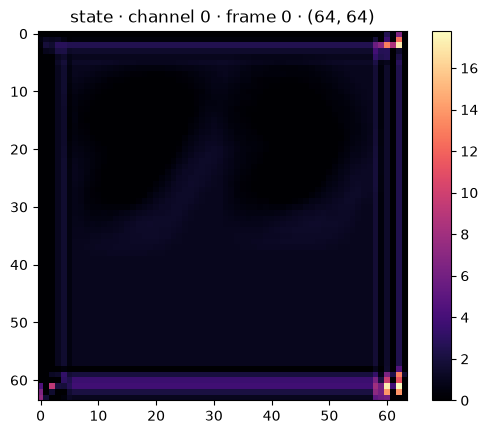

In [8]:

fmap = state[0, 0, 0].cpu()                      # video 0, feature channel 0, frame 0

plt.imshow(fmap, cmap="magma")
plt.title(f"state · channel 0 · frame 0 · {tuple(fmap.shape)}")
plt.colorbar()
plt.show()


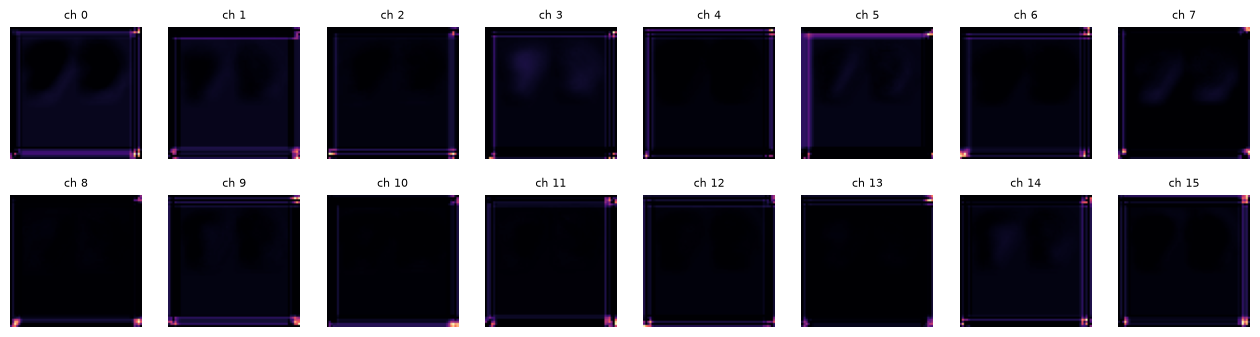

In [9]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for k, ax in enumerate(axes.flat):
    ax.imshow(state[0, k, 0].cpu(), cmap="magma")
    ax.set_title(f"ch {k}", fontsize=8)
    ax.axis("off")
plt.show()


# State

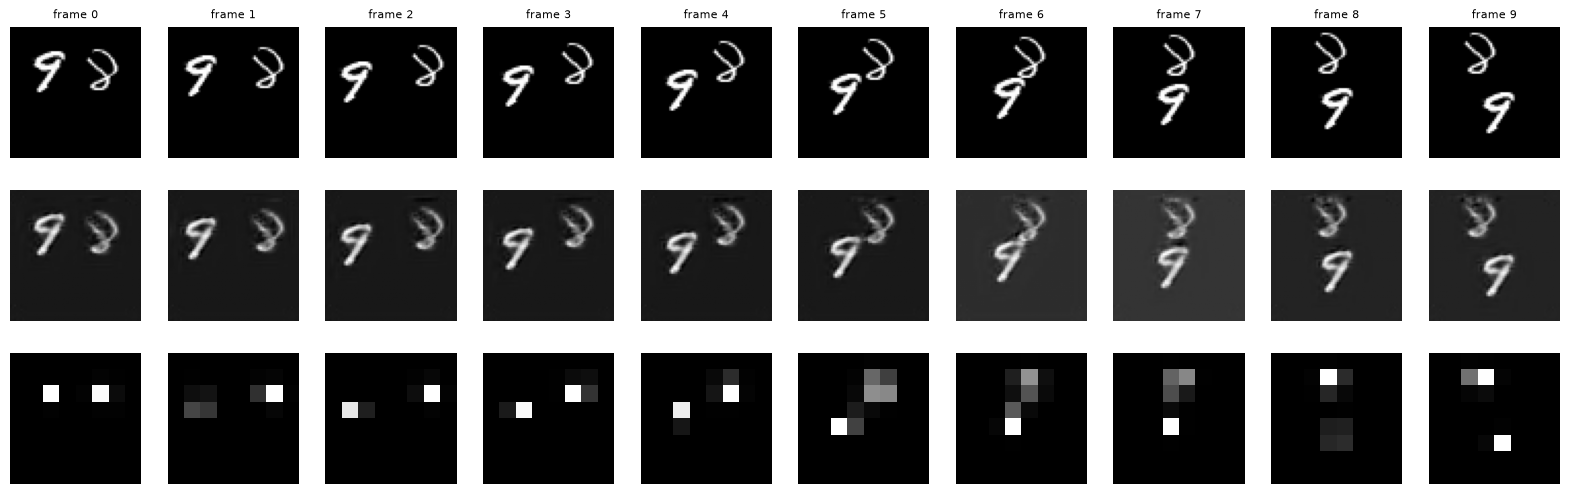

In [10]:
T = recon_video.shape[2]  # 10 frames

fig, axes = plt.subplots(3, T, figsize=(2 * T, 6))
for t in range(T):
    axes[0, t].imshow(batch["video"][0, 0, t], cmap= "gray")
    axes[1, t].imshow(recon_video[0, 0, t].cpu(), cmap= "gray")
    axes[2, t].imshow(detecting_digit[0, t].cpu(), cmap= "gray")
    axes[0, t].set_title(f"frame {t}", fontsize=8)
    for row in range(3):
        axes[row, t].axis("off")
plt.show()


# Predicted states ; One step deep 

In [11]:
predictor.eval()
decoder.eval()
dethead.eval()

with torch.no_grad(): 
    

    actions_encoded = None 
    predicted_states = predictor(state, actions_encoded)
    print(predicted_states.shape)

    recon_video = decoder(predicted_states)
    print(recon_video.shape)

    detecting_digit = dethead(predicted_states)
    print(detecting_digit.shape)


torch.Size([64, 16, 9, 64, 64])
torch.Size([64, 1, 9, 64, 64])
torch.Size([64, 9, 8, 8])


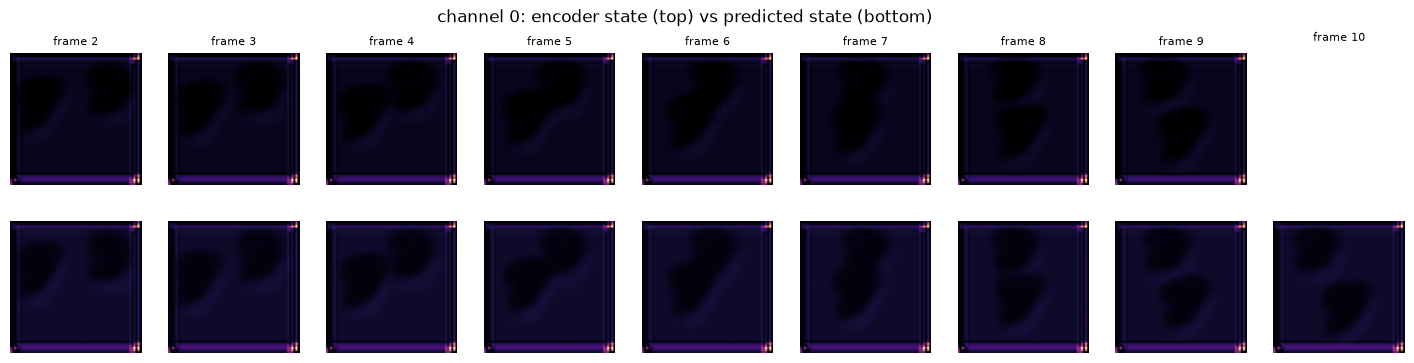

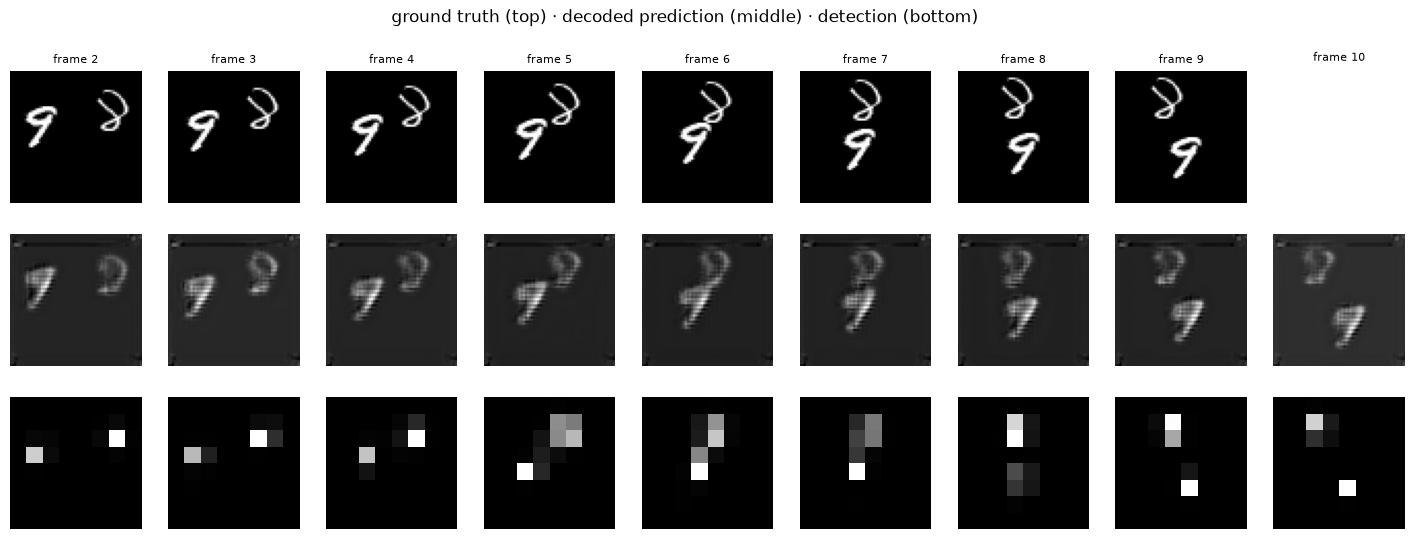

In [12]:
Tp = predicted_states.shape[2]  # 9 predictions: ŝ2 ... ŝ10
ch = 0

fig, axes = plt.subplots(2, Tp, figsize=(2 * Tp, 4))
for t in range(Tp):
    if t + 2 < state.shape[2]:  # ŝ10 has no ground truth
        axes[0, t].imshow(state[0, ch, t + 2].cpu(), cmap="magma")
    axes[1, t].imshow(predicted_states[0, ch, t].cpu(), cmap="magma")
    axes[0, t].set_title(f"frame {t + 2}", fontsize=8)
    for row in range(2):
        axes[row, t].axis("off")
fig.suptitle(f"channel {ch}: encoder state (top) vs predicted state (bottom)")
plt.show()


fig, axes = plt.subplots(3, Tp, figsize=(2 * Tp, 6))
for t in range(Tp):
    if t + 2 < batch["video"].shape[2]:  # frame 10 doesn't exist
        axes[0, t].imshow(batch["video"][0, 0, t + 2], cmap="gray")
    axes[1, t].imshow(recon_video[0, 0, t].cpu(), cmap="gray")
    axes[2, t].imshow(detecting_digit[0, t].cpu(), cmap="gray")
    axes[0, t].set_title(f"frame {t + 2}", fontsize=8)
    for row in range(3):
        axes[row, t].axis("off")
fig.suptitle("ground truth (top) · decoded prediction (middle) · detection (bottom)")
plt.show()


# VCLoss 

In [13]:
projector.eval()
with torch.no_grad(): 
    projected_state = projector(state.transpose(0,1).flatten(1).transpose(0,1))
    print(projected_state.shape)

torch.Size([2621440, 64])


In [14]:
std = torch.std(projected_state,dim=0)
std 

tensor([1.0349, 1.0045, 1.0199, 0.9930, 1.0218, 1.0355, 1.0313, 0.9986, 1.0097,
        1.0327, 1.0175, 1.0177, 1.0254, 1.0569, 1.0229, 1.0212, 1.0447, 1.0099,
        1.0171, 1.0132, 1.0176, 1.0164, 1.0186, 1.0294, 1.0096, 0.9871, 1.0361,
        1.0320, 1.0273, 0.9952, 1.0167, 1.0419, 1.0062, 1.0506, 1.0119, 1.0215,
        1.0307, 0.9969, 0.9979, 1.0089, 1.0193, 1.0452, 1.0078, 1.0031, 1.0187,
        0.9998, 1.0220, 1.0381, 1.0107, 1.0099, 1.0070, 1.0299, 1.0208, 1.0432,
        1.0078, 1.0039, 1.0084, 1.0488, 1.0241, 1.0139, 1.0066, 0.9988, 1.0200,
        1.0245], device='mps:0')

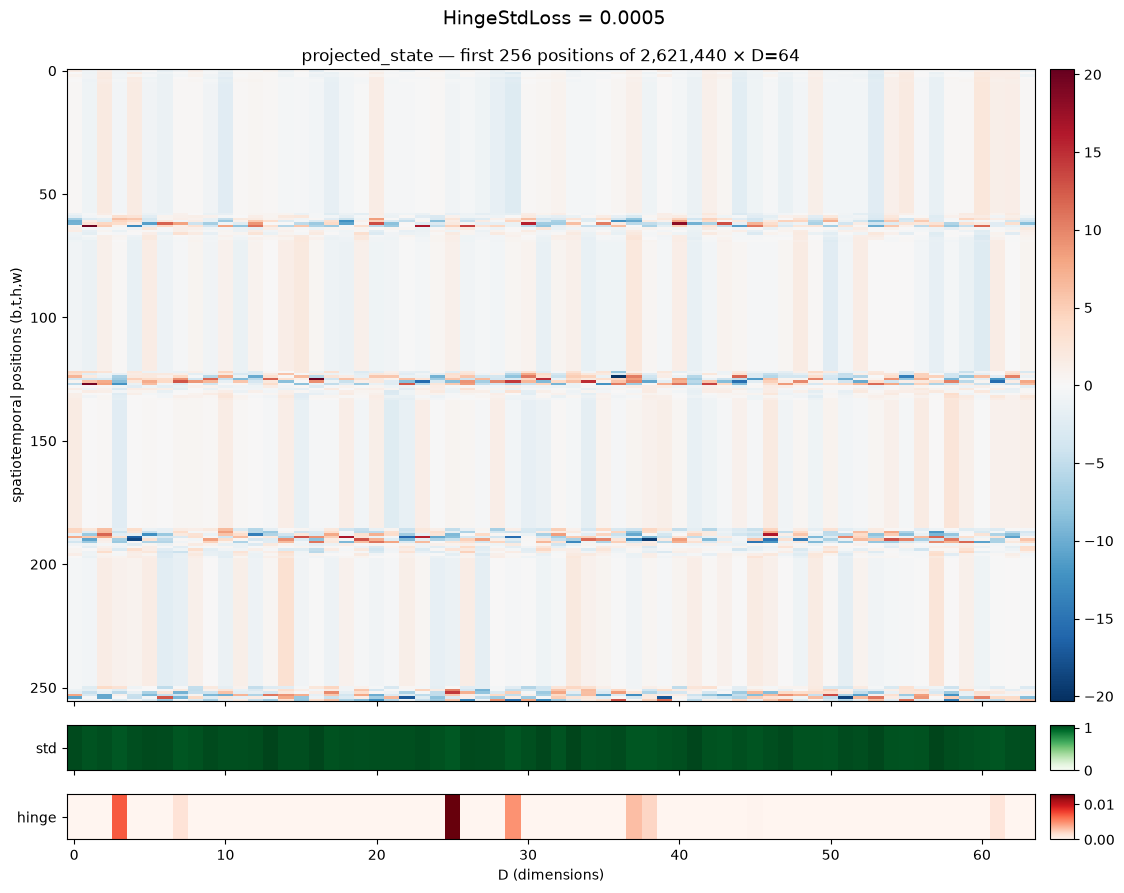

In [20]:
import torch.nn.functional as F
from mpl_toolkits.axes_grid1 import make_axes_locatable

n_show = 256  # rows to display out of 2,621,440

with torch.no_grad():
    centered = projected_state - projected_state.mean(dim=0, keepdim=True)  # same centering as HingeStdLoss
    std_all = torch.sqrt(centered.var(dim=0) + 0.0001)                      # std over ALL positions, matches the loss
    hinge = F.relu(1.0 - std_all)                                           # per-dimension penalty
    hinge_std_loss = hinge.mean().item()

sample = centered[:n_show].cpu().numpy()
std_np = std_all.cpu().numpy()
hinge_np = hinge.cpu().numpy()

fig, axes = plt.subplots(
    3, 1, figsize=(13, 10), sharex=True,
    gridspec_kw={"height_ratios": [14, 1, 1], "hspace": 0.1},
)

def add_cbar(ax, im, **kw):
    cax = make_axes_locatable(ax).append_axes("right", size="2.5%", pad=0.15)
    fig.colorbar(im, cax=cax, **kw)

# heatmap: first n_show spatiotemporal positions x dimensions, diverging map centered at 0
vmax = abs(sample).max()
im0 = axes[0].imshow(sample, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                     aspect="auto", interpolation="nearest")
axes[0].set_ylabel("spatiotemporal positions (b,t,h,w)")
axes[0].set_title(f"projected_state — first {n_show} positions of {projected_state.shape[0]:,} × D={sample.shape[1]}")
add_cbar(axes[0], im0)

# std per dimension
im1 = axes[1].imshow(std_np[None, :], cmap="Greens", vmin=0, vmax=std_np.max(),
                     aspect="auto", interpolation="nearest")
axes[1].set_yticks([0]); axes[1].set_yticklabels(["std"])
add_cbar(axes[1], im1)

# hinge = relu(1 - std) per dimension
im2 = axes[2].imshow(hinge_np[None, :], cmap="Reds", vmin=0,
                     vmax=hinge_np.max() if hinge_np.max() > 0 else 1.0,
                     aspect="auto", interpolation="nearest")
axes[2].set_yticks([0]); axes[2].set_yticklabels(["hinge"])
axes[2].set_xlabel("D (dimensions)")
add_cbar(axes[2], im2)

fig.suptitle(f"HingeStdLoss = {hinge_std_loss:.4f}", fontsize=14, y=0.94)
plt.show()
